In [1]:
from platform import python_version
print(python_version())

3.11.14


### BayesPrism

#### **Bayesian cell Proportion Reconstruction** Inferred using Statistical Marginalization (BayesPrism):

A Fully Bayesian Inference of Tumor Microenvironment composition and gene expression

BayesPrism consists of 
- the deconvolution modules and 
- the embedding learning module. 

The **deconvolution module** models a prior from cell type-specific expression profiles from scRNA-seq to jointly estimate the posterior distribution of cell type composition and cell type-specific gene expression from bulk RNA-seq expression of tumor (or non-tumor) samples. 

The **embedding learning** module uses Expectation-maximization (EM) to approximate the tumor expression using a linear combination of malignant gene programs while conditional on the inferred expression and fraction of non-malignant cells estimated by the deconvolution module.


#### Ref

Cell type and gene expression deconvolution with BayesPrism enables Bayesian integrative analysis across bulk and single-cell RNA sequencing in oncology

Chu, T. et al. & Danko, C.G.

https://www.nature.com/articles/s43018-022-00356-3


#### Concepts (paper)

Two layers of information are critical for understanding tumor composition: (1) the proportion of each cell type and (2) the levels of gene expression in each cell type. The rise of single-cell RNA sequencing (scRNA-seq) technologies has recently enabled direct, genome-wide measurement of the transcriptome in individual
cells within the TME and characterization of their heterogeneity. However, the cost of scRNA-seq and requirements for high-quality tissue limit the number of patient samples that can be assayed9. Moreover, **scRNA-seq is susceptible to technical biases in cell capture** 9 , which confound the recovery of cell type composition.

### Github

https://github.com/Danko-Lab/BayesPrism

- tutorial_deconvolution.html
- tutorial_embedding_learning.html


### Z (Posteior) and Gibbs distribution


Two different estimators, and the difference is mechanical.

#### **Fitted genes** (# 1918).

Gibbs sampling draws `Z[s,g,c]` from a posterior informed by *that sample's own bulk count for that gene*. If sample A's tumour genuinely expresses gene g more than sample B's, the data can say so. Where evidence is weak, the posterior shrinks toward the reference — but the shrinkage is evidence-dependent, and the estimate is compartment-specific.

#### **Projected genes** (the other #15432 = 17540-1918)
`full_Z` allocates the observed bulk count across compartments using weights built from `theta[s]` and the *fixed* reference `phi[g]`:

```
Z[s,g,c] ≈ X_bulk[s,g] · (theta[s,c] · phi[g,c]) / Σ_c' (theta[s,c'] · phi[g,c'])
```

Nothing in that expression carries sample-specific information about *which compartment* expresses gene g in sample s. Sample-to-sample variation has exactly two sources: variation in bulk expression, and variation in composition. The compartment assignment itself is the reference, applied identically to every sample.

**So yes, this can cause errors**, in a specific way. Take logs:

```
log Z[s,g,mal] − log Z[s,g,fib] = log(theta_mal[s]/theta_fib[s]) + log(phi[g,mal]/phi[g,fib])
```

A sample term plus a gene term, additive and separable. After compartment-CPM and per-gene centring, both cancel — meaning the malignant and fibroblast matrices should be **nearly identical for projected genes**. Any DE contrast run on them would return the same answer regardless of which compartment you think you're analysing.

Your `X_fib2` is 9959 genes, so ~85% are projected. Test it directly:

```python
g = X_mal2.columns.intersection(X_fib2.columns)
zm = ((X_mal2[g] - X_mal2[g].mean()) / X_mal2[g].std())
zf = ((X_fib2[g] - X_fib2[g].mean()) / X_fib2[g].std())
r = pd.Series({c: zm[c].corr(zf[c]) for c in g})

fitted = set(res.cell_type_expression(cmap["fibroblast"]).index)
print("fitted   genes, median r:", r[r.index.isin(fitted)].median().round(3))
print("projected genes, median r:", r[~r.index.isin(fitted)].median().round(3))
```

If projected genes come back near r=1 and fitted genes clearly below, then the 367 stroma hits and the 7 tumour hits are largely the same bulk contrast wearing two labels, and cross-compartment analyses should be restricted to the 1604 fitted genes.

I should flag that this is my reading of what `full_Z` must be doing — you wrote it, so check the actual allocation. If it does something more elaborate than reference-weighted splitting, the algebra changes.

### Single-cell quality: MAESTRO

MAESTRO (Model-based AnalysEs of Single-cell Transcriptome and RegulOme) is a Snakemake-based pipeline that processes single-cell RNA-seq and ATAC-seq data from raw FASTQ files through alignment, quality control, cell filtering, clustering, and cell-type annotation.

https://liulab-dfci.github.io/MAESTRO/

### TISCH2

https://tisch.compbio.cn/gallery/?cancer=PAAD&celltype=Acinar&celltype=Ductal&species=Human&treatment=None&primary=Primary


Peng J, Sun BF, Chen CY, Zhou JY, Chen YS, Chen H, Liu L, Huang D, Jiang J, Cui GS, Yang Y, Wang W, Guo D, Dai M, Guo J, Zhang T, Liao Q, Liu Y, Zhao YL, Han DL, Zhao Y, Yang YG, Wu W. Single-cell RNA-seq highlights intra-tumoral heterogeneity and malignant progression in pancreatic ductal adenocarcinoma. Cell Res. 2019 Sep;29(9):725-738. doi: 10.1038/s41422-019-0195-y. Epub 2019 Jul 4. Erratum in: Cell Res. 2019 Sep;29(9):777. doi: 10.1038/s41422-019-0212-1. PMID: 31273297; PMCID: PMC6796938.

### We have a problem !

> The reference is the hard half. Peng CRA001160 is symbol-indexed, and it's the pre-2018 symbols we just diagnosed.  
> Moving the df_bulk to ENSG doesn't help unless the reference moves too — otherwise the intersection goes to zero.  
> So you still need one symbol→ENSG mapping for the reference,  
> and it should use an archived Ensembl release (~92/93, contemporary with Peng),  
> not a current service, for the same reason the two-step round-trip was risky. 

#### ENSG IDs need normalising.

Peng J, Sun BF, Chen CY, Zhou JY, Chen YS, Chen H, Liu L, Huang D, Jiang J, Cui GS, Yang Y, Wang W, Guo D, Dai M, Guo J, Zhang T, Liao Q, Liu Y, Zhao YL, Han DL, Zhao Y, Yang YG, Wu W. Single-cell RNA-seq highlights intra-tumoral heterogeneity and malignant progression in pancreatic ductal adenocarcinoma. Cell Res. 2019 Sep;29(9):725-738. doi: 10.1038/s41422-019-0195-y. Epub 2019 Jul 4. Erratum in: Cell Res. 2019 Sep;29(9):777. doi: 10.1038/s41422-019-0212-1. PMID: 31273297; PMCID: PMC6796938.


In [2]:
import os, sys, yaml
from pathlib import Path
from dotenv import load_dotenv

import numpy as np
import pandas as pd
pd.set_option('display.width', 100)
pd.set_option('max_colwidth', 80)
pd.set_option("display.precision", 3)

import seaborn as sns
sns.set_context("notebook", font_scale=1.4)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

ROOT0 = Path("/home/flavio/uv/perturb_agent/")
ROOT_SRC = ROOT0 / "src"

sys.path.insert(0, ROOT_SRC)


if str(ROOT_SRC) not in sys.path:
    sys.path.append(str(ROOT_SRC))

print("ROOT0:", ROOT0)
print("ROOT_SRC added:", ROOT_SRC)

from libs.Basic import create_dir
from libs.MTD_lib import MTD
from libs.cBioPortal_lib import cBioPortal
from libs.calc_degs_lib import CALC_DEGS
# from libs.dashcyto_lib import DASH_CYTO
from libs.config_lib import Config
from libs.prism_lib import PRISM
from libs.prism_program_lib import *


from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))

with open('../params.yml', 'r') as file:
    dic_yml = yaml.safe_load(file)

# print(dic_yml)

ROOT0: /home/flavio/uv/perturb_agent
ROOT_SRC added: /home/flavio/uv/perturb_agent/src


/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/Bio/__init__.py:138: BiopythonWarning: You may be importing Biopython from inside the source tree. This is bad practice and might lead to downstream issues. In particular, you might encounter ImportErrors due to missing compiled C extensions. We recommend that you try running your code from outside the source tree. If you are outside the source tree then you have a pyproject.toml file in an unexpected directory: /home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages
  warnings.warn(
/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
email = os.getenv('email')

i_project=0

project_list = dic_yml['project_list']
n = len(project_list)
project = project_list[i_project]

s_project_list = dic_yml['s_project_list']
s_project = s_project_list[i_project]
assert n==len(project_list), f"Error project_list: there are {n} projects"

PROG_ID = 'TCGA'
PSI_ID = 'BRCA'
PSI_ID = 'ACC'
PSI_ID = 'CESC'
PSI_ID = 'PAAD'

ROOT0_DATA = ROOT0 / "data"
root_colab = ROOT0_DATA / 'colab'
root_project = ROOT0_DATA / PROG_ID

disease = PSI_ID

root_project = create_dir(ROOT0_DATA, s_project)
root_disease = create_dir(root_project, PSI_ID)

CONTEXT_DISESE = 'xxxx'
context_disease = CONTEXT_DISESE

gene_protein = dic_yml['gene_protein']
s_omics = dic_yml['s_omics']

has_age = dic_yml['has_age']
has_gender = dic_yml['has_gender']

exp_normalization = dic_yml['exp_normalization']
normalization = 'quantile_norm' if exp_normalization == True else 'not_normalized'

LFC_cut_inf = dic_yml['LFC_cut_inf']
s_pathw_enrichm_method = dic_yml['s_pathw_enrichm_method']
ptw_min_num_of_degs_cut = dic_yml['ptw_min_num_of_degs_cut']

tolerance_pPMI = dic_yml['tolerance_pPMI']
type_sat_ptw_index = dic_yml['type_sat_ptw_index']
saturation_lfc_param = dic_yml['saturation_lfc_param']

pval_pathway_cutoff = dic_yml['pval_pathway_cutoff']
fdr_pathway_cutoff = dic_yml['fdr_pathway_cutoff']
num_of_genes_cutoff = dic_yml['num_of_genes_cutoff']
enr_db_list = dic_yml['enr_db_list']


case_list = dic_yml['case_list']
dic_case_list = dic_yml['dic_case_list']

std_filename      = dic_yml['std_filename']
std_filename_list = dic_yml['std_filename_list']

min_lfc_modulation = dic_yml['min_lfc_modulation']
num_of_genes_list  = dic_yml['num_of_genes_list']
pPMI_normalized  = dic_yml['pPMI_normalized']

#--- max len for formatting purposes
s_len_case  = dic_yml['s_len_case']

n_sentences = dic_yml['n_sentences']
run_list = dic_yml['run_list']
chosen_model_list = dic_yml['chosen_model_list']
i_dfp_list = dic_yml['i_dfp_list']
chosen_model_sampling = dic_yml['chosen_model_sampling']

fdr_ptw_cutoff_list = np.arange(0.05, 0.80, 0.05)
lfc_list = np.round(np.arange(1.0, -0.01, -.025), 3)
fdr_list = np.arange(0.05, 0.76, .01)

cfg = Config(root0=ROOT0, root_disease=root_disease, disease=disease, case_list=case_list)
case = case_list[0]

n_genes_annot_ptw, n_degs, n_degs_in_ptw, n_degs_not_in_ptw, degs_in_all_ratio = -1,-1,-1,-1,-1

LFC_cut, lfc_FDR_cut, n_degs, n_degs_up, n_degs_dw = cfg.get_best_lfc_cutoff(case, 'not_normalized')

print(f"project '{project}', s_project '{s_project}'")
print(f"G/P LFC cutoffs: lfc={LFC_cut:.3f}; fdr={lfc_FDR_cut:.3f} - LFC_cut_inf={LFC_cut_inf:.3f}")
print(f"Pathway cutoffs: pval={pval_pathway_cutoff:.3f}; fdr={fdr_pathway_cutoff:.3f}; num of genes={num_of_genes_cutoff}")

Best parameter file for LFC does not exist /home/flavio/uv/perturb_agent/data/TCGA/PAAD/config/all_lfc_cutoffs_PAAD.tsv
project 'TCGA', s_project 'TCGA'
G/P LFC cutoffs: lfc=1.000; fdr=0.050 - LFC_cut_inf=0.400
Pathway cutoffs: pval=0.050; fdr=0.050; num of genes=3


In [4]:
mtd = MTD(disease=disease, gene_protein=gene_protein, s_omics=s_omics, project=project, s_project=s_project, 
          root0=ROOT0, root0_data=ROOT0_DATA, prog_id=PROG_ID, psi_id=PSI_ID,
          case_list=case_list, dic_case_list=dic_case_list, has_age=has_age, has_gender=has_gender, exp_normalization=exp_normalization,
          std_filename=std_filename, std_filename_list=std_filename_list,
          geneset_num=0, ptw_min_num_of_degs_cut=ptw_min_num_of_degs_cut,
          tolerance_pPMI=tolerance_pPMI, s_pathw_enrichm_method=s_pathw_enrichm_method,
          LFC_cut_inf=LFC_cut_inf, fdr_ptw_cutoff_list=fdr_ptw_cutoff_list,
          num_of_genes_list=num_of_genes_list, lfc_list=lfc_list, fdr_list=fdr_list, 
          min_lfc_modulation=min_lfc_modulation, type_sat_ptw_index=type_sat_ptw_index,
          saturation_lfc_param=saturation_lfc_param, enr_db_list=enr_db_list, pPMI_normalized=pPMI_normalized)

print(">>> Roots", mtd.root0, mtd.root_disease)
case = case_list[0]
print(">>>", mtd.disease, case)

mtd.cfg.set_default_best_lfc_cutoff(mtd.normalization, LFC_cut=1, lfc_FDR_cut=0.05)
ret, degs, degs_ensembl, dfdegs = mtd.open_case(case, prompt_verbose=True, verbose=False)
print("\nEcho Parameters:")
print(mtd.echo_parameters())

>>> Roots /home/flavio/uv/perturb_agent /home/flavio/uv/perturb_agent/data/TCGA/PAAD
>>> PAAD Tumor
>>> case Tumor
>>> psi_id or disease: PAAD
Error: No data available for the specified PAAD.
Error: could not find /home/flavio/uv/perturb_agent/data/TCGA/PAAD/lfc/PAAD_final_LFC_Tumor_x_CTRL_not_normalized.tsv
No dflfc table was calculated for this case Tumor

Echo Parameters:
	0/0 DEGs/ensembl.
		Up 0/0 DEGs/ensembl.
		Dw 0/0 DEGs/ensembl.

Found 0 (best=3) pathways for geneset num=0 'Reactome_Pathways_2024'
Pathway cutoffs p-value=0.050 fdr=0.050 min genes=0.05No enrichment analysis was calculated.


In [5]:
cbio = cBioPortal(root0=ROOT0, root0_data=ROOT0_DATA, memory_restriction=False)

### Get all programs

In [6]:
verbose = False

df_psi = cbio.open_primary_site(verbose=verbose)
df_psi

,prog_id,cbioportal_study_id,active,gdc_project_id,psi_id,disease_id,disease_cd,primary_site,disease_context
0,TCGA,paad_tcga_pan_can_atlas_2018,True,TCGA-PAAD,PAAD,pancreatic_adenocarcinoma,PAAD,Pancreas,"TCGA pancreatic adenocarcinoma, PanCancer Atlas"
1,CPTAC3,paad_cptac_2021,True,CPTAC-3,PAAD,pancreatic_ductal_adenocarcinoma,PAAD,Pancreas,"CPTAC publication cohort, Cell 2021; 140 pancreatic cancers"
2,TCGA,skcm_tcga_pan_can_atlas_2018,True,TCGA-SKCM,SKCM,cutaneous_melanoma,SKCM,Skin,"TCGA skin cutaneous melanoma, PanCancer Atlas"
3,TCGA,brca_tcga_pan_can_atlas_2018,True,TCGA-BRCA,BRCA,breast_invasive_carcinoma,BRCA,Breast,"TCGA breast invasive carcinoma, PanCancer Atlas"
4,CPTAC2,brca_cptac_2020,True,CPTAC-2,BRCA,breast_cancer,BRCA,Breast,"CPTAC breast cancer publication cohort, Cell 2020"


### Open primary cites from cbio

In [7]:
PROG_ID = 'TCGA'
psi_id = 'PAAD'
psi_id = 'SKCM'
psi_id = 'BRCA'

PROG_ID = 'CPTAC2'
psi_id = 'BRCA'

PROG_ID = 'CPTAC3'
psi_id = 'PAAD'

### Prism Class instantitaion

https://github.com/Danko-Lab/BayesPrism

In [8]:
prism = PRISM(root0=ROOT0, root0_data=ROOT0_DATA)

verbose=True

prism.set_program_and_primary_site(prog_id=PROG_ID, psi_id=psi_id, verbose=verbose)

prism.root_prism, prism.root_prism.exists()

Table opened ((7, 9)) at '/home/flavio/uv/perturb_agent/data/cbioportal_study_mapping.tsv'

-----------------------------
>> prog_id: CPTAC3
>> psi_id: PAAD
>> primary_site: Pancreas
>> disease_id: pancreatic_ductal_adenocarcinoma
>> disease_cd: PAAD

-----------------------------
>> cbioportal_study_id: paad_cptac_2021
>> gdc_project_id: CPTAC-3

-----------------------------
>> root disease: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD
>> root samples: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/samples
>> root lfc: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/lfc
>> root mutations: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/mutations
-----------------------------



(PosixPath('/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism'), True)

### Running prism

In [9]:
verbose=True

res = prism.open_bayesprism(verbose=verbose)
print(len(res.genes))

Loaded /home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism/deconv.h5ad (8.1 MB)
1918


In [10]:
res.states

['Fibroblast cell',
 'Stellate cell',
 'Macrophage cell',
 'Endothelial cell',
 'T cell',
 'B cell',
 'Ductal cell type 2',
 'Endocrine cell',
 'Ductal cell type 1',
 'Acinar cell']

In [11]:
res.theta_type.columns

Index(['Acinar cell', 'B cell', 'Ductal cell type 1', 'Endocrine cell', 'Endothelial cell',
       'Fibroblast cell', 'Macrophage cell', 'Stellate cell', 'T cell', 'malignant'],
      dtype='object')

In [12]:
print(res.theta.shape)
res.theta.head(5)

(153, 10)


,Fibroblast cell,Stellate cell,Macrophage cell,Endothelial cell,T cell,B cell,Ductal cell type 2,Endocrine cell,Ductal cell type 1,Acinar cell
T-C3L-02890,0.603,8.666e-03,0.025,0.029,8.828e-73,0.018,0.105,1.176e-152,1.083e-01,0.104
T-C3L-03635,0.760,5.456e-03,0.016,0.028,2.978e-163,0.008,0.183,4.146e-105,2.173e-72,0.000
T-C3L-02701,0.763,1.275e-08,0.027,0.015,1.957e-222,0.005,0.175,1.414e-02,1.685e-148,0.000
T-C3L-04072,0.296,1.671e-02,0.076,0.034,1.428e-144,0.036,0.514,0.000e+00,2.690e-02,0.001
T-C3L-00589,0.384,4.344e-02,0.048,0.036,2.727e-125,0.014,0.422,1.177e-296,1.481e-02,0.038


In [13]:
res.theta.tail(5)

,Fibroblast cell,Stellate cell,Macrophage cell,Endothelial cell,T cell,B cell,Ductal cell type 2,Endocrine cell,Ductal cell type 1,Acinar cell
N-C3L-02606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
N-C3N-03173,0.003,0.040,0.002,0.007,2.048e-85,4.374e-03,0.929,0.000,0.013,3.553e-114
N-C3N-02696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
N-TCGA-H6-8124,0.581,0.014,0.089,0.030,4.796e-138,4.272e-16,0.094,0.004,0.153,3.388e-02
N-TCGA-H6-A45N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Ductal cell type 1

"Ductal cell type 1" is the normal-like ductal population and stays in the environment compartment — which is what you want. If both had been mapped to malignant, purity would inflate. Verify with res.tumor_purity.groupby(meta["condition"]).describe(): normals near zero, tumors somewhere in 0.2–0.6.


### Ductal cell type 2

One malignant state means no Ductal cell type 2 subdivision, so subtype_malignant scores Moffitt signatures on a single pooled malignant profile. That still works — it's per-sample expression, so samples can differ — but it won't give you distinct malignant states in θ. For that you'd subcluster Ductal cell type 2 in the AnnData and write finer cell_state labels before calling pseudobulk_reference.

In [14]:
res.cell_type_expression("Ductal cell type 1").shape

(1918, 153)

In [15]:
res.cell_type_expression("Ductal cell type 1").head(3)

,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
ENSG00000000938,51.301,NaN,NaN,37.533,71.738,133.775,NaN,103.585,65.544,NaN,...,NaN,42.916,38.229,NaN,NaN,NaN,39.535,NaN,81.539,NaN
ENSG00000001617,46.895,NaN,NaN,139.224,37.504,111.861,NaN,48.340,100.671,NaN,...,NaN,56.004,34.789,NaN,NaN,NaN,33.189,NaN,84.933,NaN
ENSG00000001626,98976.750,NaN,NaN,60517.504,64058.141,12317.005,NaN,85658.117,93382.445,NaN,...,NaN,44093.203,37337.992,NaN,NaN,NaN,32737.848,NaN,77932.102,NaN


In [16]:
res.cell_type_expression("Ductal cell type 2").shape

(1918, 153)

In [17]:
res.cell_type_expression("Ductal cell type 2").head(3)

,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
ENSG00000000938,105.698,49.471,169.428,75.978,130.365,249.999,127.351,187.454,110.75,131.444,...,NaN,60.164,65.509,NaN,NaN,NaN,95.958,NaN,204.643,NaN
ENSG00000001617,211.804,188.735,283.416,617.821,149.403,458.264,447.011,191.767,372.90,247.584,...,NaN,172.114,130.685,NaN,NaN,NaN,176.593,NaN,467.284,NaN
ENSG00000001626,4642.306,1529.108,865.661,2788.810,2650.019,523.997,1481.312,3528.819,3592.04,1061.946,...,NaN,1407.204,1456.537,NaN,NaN,NaN,1808.896,NaN,4452.575,NaN


### 2. theta is now fixed -> expand Z to every gene

In [18]:
verbose=False
force=False

imax_tumor=250
imax_normal=50

exclude_prog_list=['CCLE']
disease_cd = 'PAAD'

dfn_tumor, dfn_normal, df_gtex, df_summ = cbio.get_all_data_from_disease(disease_cd=disease_cd, 
                                                           imax_tumor=imax_tumor, imax_normal=imax_normal,
                                                           exclude_prog_list=exclude_prog_list,
                                                           force=force, verbose=verbose)

Error reading csv/tsv '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/expression_gtex_controls_counts.tsv': No columns to parse from file


In [19]:
print(dfn_tumor.shape)
dfn_tumor.head(3)

(60616, 134)


,geneid,symbol,biotype,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,...,T-TCGA-HZ-7289,T-TCGA-3A-A9IN,T-TCGA-3A-A9IS,T-TCGA-2L-AAQM,T-TCGA-3A-A9IR,T-TCGA-3A-A9IV,T-TCGA-3A-A9IO,T-TCGA-2J-AABT,T-TCGA-H6-A45N,T-TCGA-3A-A9IJ
0,ENSG00000000003,TSPAN6,protein_coding,1486,2083,1558,546,1208,648,896,...,2506,442,38,299,77,158,394,659,1294,395
1,ENSG00000000005,TNMD,protein_coding,12,97,15,1,14,2,5,...,2,172,4,2,1,2,14,3,3,0
2,ENSG00000000419,DPM1,protein_coding,1330,1521,1499,986,1388,974,649,...,1638,940,1372,1008,1493,1059,922,839,717,1034


In [20]:
print(dfn_normal.shape)
dfn_normal.head(3)

(60616, 25)


,geneid,symbol,biotype,N-C3L-04072,N-C3L-00589,N-C3L-03123,N-C3L-04080,N-C3L-00640,N-C3N-01719,N-C3L-07033,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
0,ENSG00000000003,TSPAN6,protein_coding,1633,1302,1079,1367,896,1188,1275,...,891,1063,1261,1821,554,1244,977,1576,3738,369
1,ENSG00000000005,TNMD,protein_coding,0,8,9,3,4,7,0,...,0,7,2,6,1,1,3,39,4,5
2,ENSG00000000419,DPM1,protein_coding,1281,937,655,956,1000,1504,1087,...,703,601,1059,1289,342,773,676,783,1532,1023


In [21]:
print(df_gtex.shape)
df_gtex.head(3)

(0, 0)


""


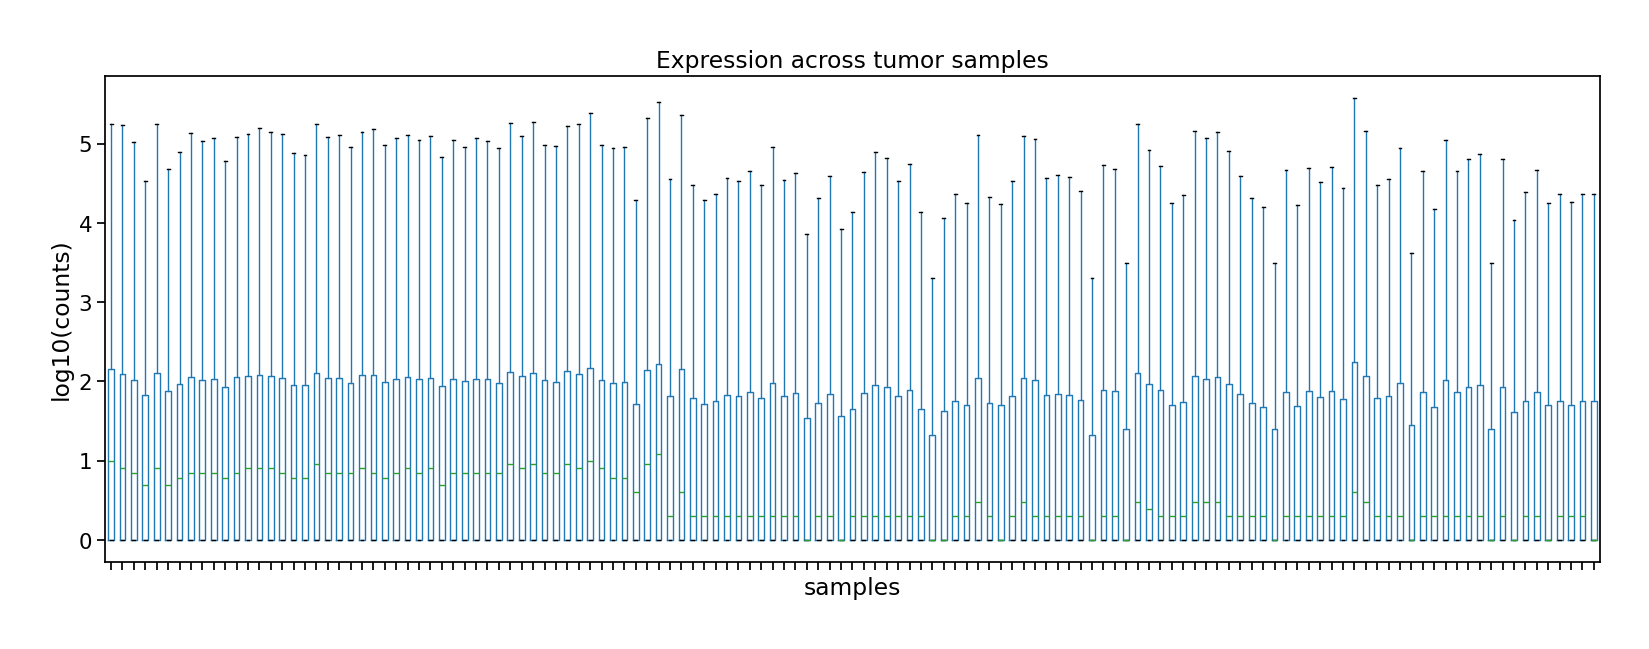

In [22]:
cbio.plot_boxplot_expression(dfn_tumor, do_log10=True, title = "Expression across tumor samples")

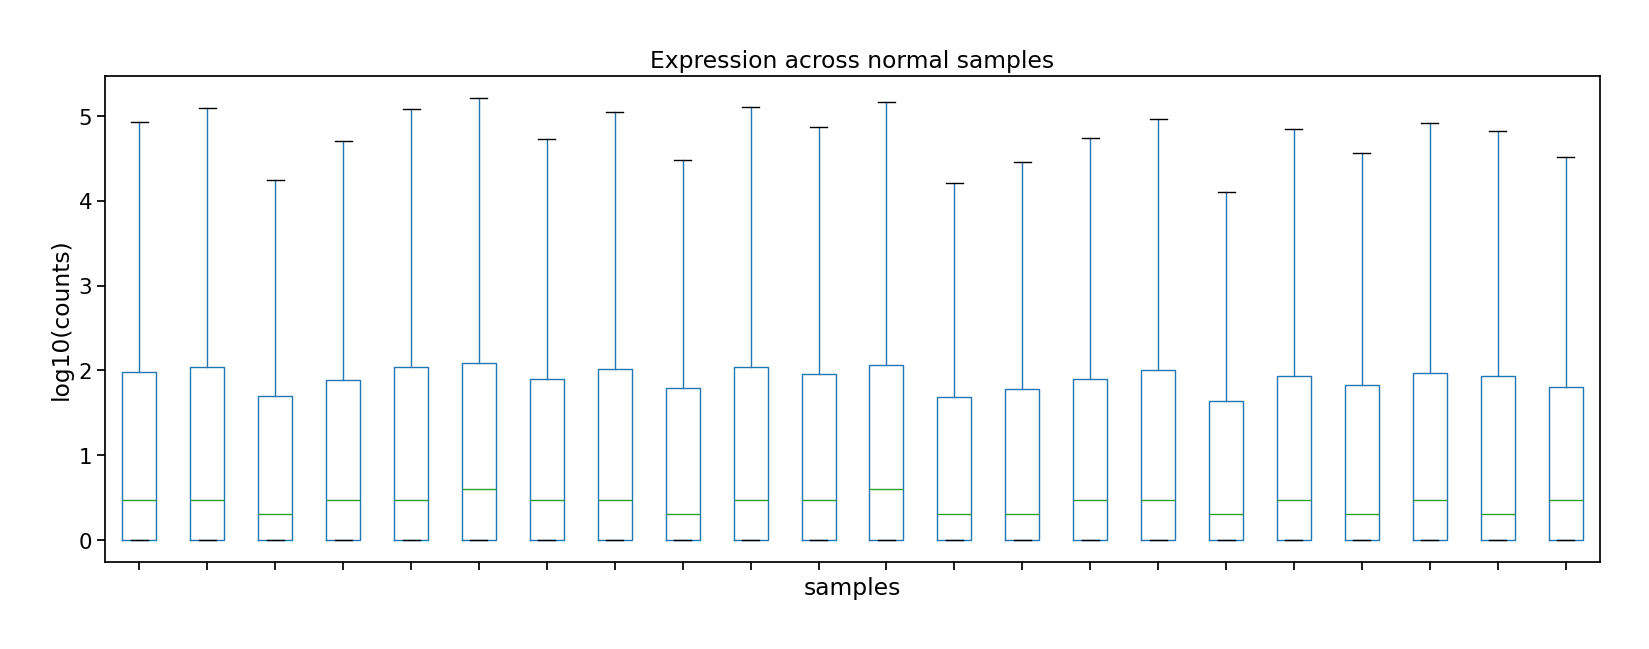

In [23]:
cbio.plot_boxplot_expression(dfn_normal, do_log10=True, title = "Expression across normal samples")

### Bulk - by geneid

In [24]:
force=False
verbose=True

df_bulk, df_meta = prism.build_bulk_matrix(dfn_tumor, dfn_normal, cbio.df_metadata, 
                                        keep_biotypes=("protein_coding", "lncRNA", "miRNA"),
                                        gene_key="geneid", force=force, verbose=verbose)

#--- reference geneid --> 
gene_map = prism.load_gene_map("geneid")
print(df_bulk.shape)
df_bulk.head(2)

Table opened ((27177, 153)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism/bulk_matrix_geneid.tsv'
Table opened ((153, 4)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism/bulk_metadata_geneid.tsv'
(27177, 153)


,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,1486,2083,1558,546,1208,648,896,1532,821,1217,...,891,1063,1261,1821,554,1244,977,1576,3738,369
ENSG00000000005,12,97,15,1,14,2,5,6,3,11,...,0,7,2,6,1,1,3,39,4,5


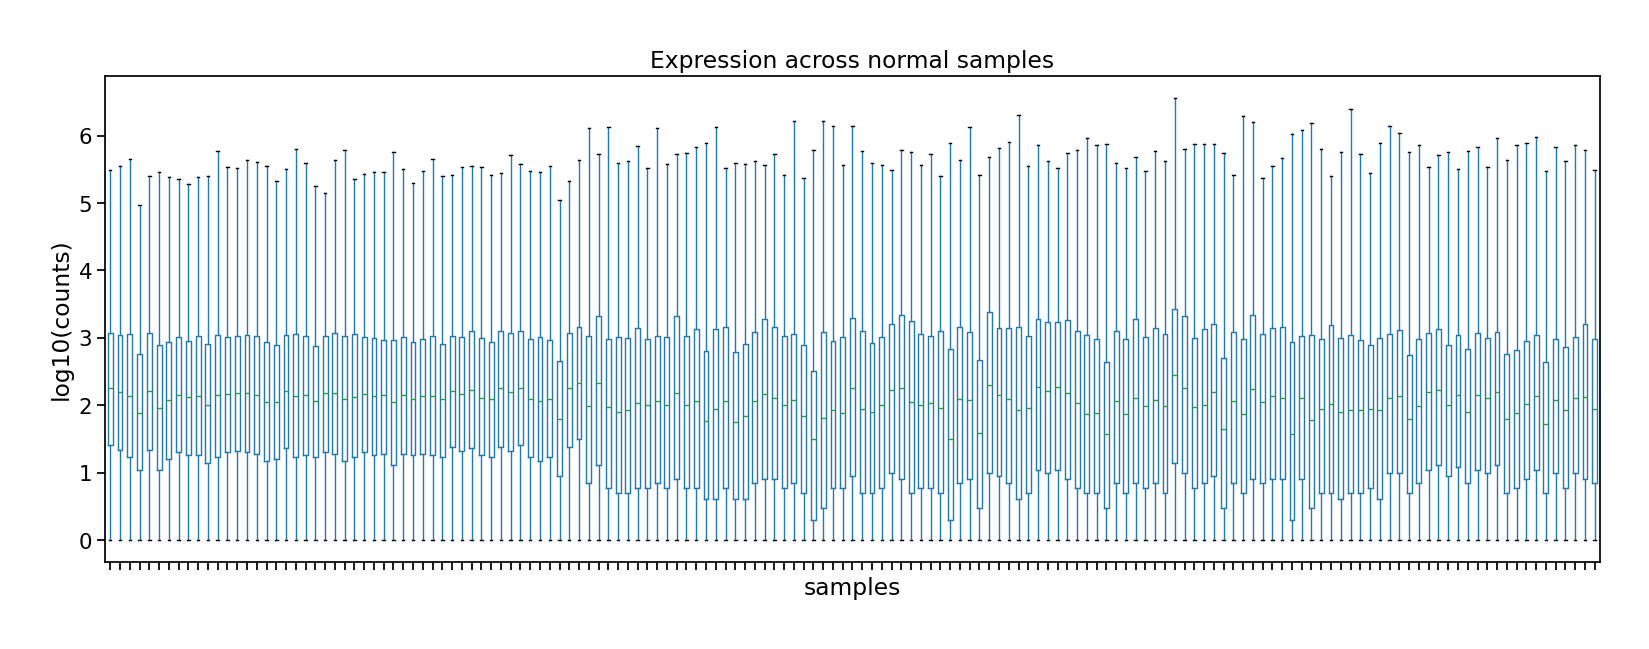

In [25]:
cbio.plot_boxplot_expression(df_bulk, do_log10=True, title = "Expression across normal samples")

### Prism single-cell data reference - Peng 2019

load_cra001160.py  

Convert the Peng 2019 GSA deposit into an AnnData ready for
`paad_deconv.pseudobulk_reference()`.

Input (from ftp://download.big.ac.cn/gsa/CRA001160/):
- count-matrix.txt   2.77 GB dense TSV, genes x cells
- all_celltype.txt   2.1 MB, per-cell annotation

The matrix is dense text: ~20k genes x ~57k cells is ~1.1e9 values, which is 10-13 GB as a dense float array but well under 1 GB as CSR, since scRNA counts are >90% zeros. So it is parsed in row chunks and sparsified incrementally -- never materialised dense.

```Bash
lftp -e "cls -l; quit" ftp://download.big.ac.cn/gsa/CRA001160/

lftp -e "pget -n 8 -c count-matrix.txt; \
         get all_celltype.txt; get md5sum.txt; quit"      ftp://download.big.ac.cn/gsa/CRA001160/

In [26]:
force=False
verbose=True

fname = "count-matrix.txt"
adata = prism.load_matrix(fname=fname, sep=' ', force=force, verbose=verbose)

fname_ad = fname.replace('.txt', '.h5ad')
filename_ad = prism.root_prism / fname_ad
compression = "gzip"


verbose=True
fname_celltype = "all_celltype.txt"
adata_ct = prism.attach_celltypes(adata=adata, fname_celltype=fname_celltype, verbose=verbose)

adata_ct

57,530 cells x 24,005 genes | obs: []
all_celltype.txt columns: ['cluster']
                             cluster
cell.name                           
T1_AAACCTGAGATGTCGG  Fibroblast cell
T1_AAACGGGGTCATGCAT    Stellate cell
T1_AAAGATGCATGTTGAC  Macrophage cell
using type_col='cluster'
barcode overlap: 57,530 / 57,530
cell_type
malignant             11315
Ductal cell type 1    10317
Endothelial cell       9117
Fibroblast cell        6742
Stellate cell          5907
Macrophage cell        5361
T cell                 3660
B cell                 2447
Acinar cell            1935
Endocrine cell          729
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 57530 × 24005
    obs: 'cluster', 'cell_type', 'cell_state'

### Reference

In [27]:
ref, s2t = prism.pseudobulk_reference(adata_ct)

print(ref.shape)
ref.head(3)

(10, 23789)


gene,AL627309.1,AP006222.2,RP11-206L10.3,RP11-206L10.2,RP11-206L10.9,LINC00115,FAM41C,RP11-54O7.3,SAMD11,NOC2L,...,RP11-133N21.10,TMEM5-AS1,RP11-175P13.2,TBC1D4-AS1,RP11-329J18.3,RP11-227G15.2,RP11-686D22.5,KRT222,RP11-799B12.2,CTC-429C10.2
cell_state,,,,,,,,,,,,,,,,,,,,,
Fibroblast cell,64.0,1612.0,42.0,22.0,30.0,214.0,102.0,103.0,1246.0,2337.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Stellate cell,44.0,903.0,25.0,16.0,30.0,162.0,55.0,13.0,112.0,1719.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Macrophage cell,141.0,696.0,81.0,29.0,22.0,182.0,124.0,5.0,35.0,1293.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


###  nnls_deconvolve()

It's the baseline cross-check — deliberately not part of the main path. It's there so you can ask "is my reference sane?" without trusting the engine you're validating.

What it computes. For each sample independently, it solves

min_w  ||Φᵀw − b_s||²    subject to  w ≥ 0

where b_s is the sample's CPM vector and Φᵀ is the genes × states signature matrix (each state row CPM-normalized). Then it rescales w to sum to 1. That's the dtangle / CIBERSORT family: linear unmixing under a Gaussian loss.

How it differs from prism_em, which matters more than it looks:

|	      | nnls_deconvolve	 |prism_em |
|---------|------------------|---------|
| loss	  | L2 on CPM	| multinomial on counts |
| gene weighting | high-expression genes dominate | Poisson variance weights each gene naturally |
| simplex	|  imposed post hoc by rescaling | enforced every iteration |
| malignant reference | fixed | sample-specific (stage 2) |

The L2-on-CPM part is the substantive difference. A gene at 5,000 CPM contributes ~10⁶× more residual than one at 5 CPM, so NNLS is effectively fit on a few dozen highly-expressed genes regardless of how informative they are. The multinomial likelihood weights each gene by its own expected count, which is the correct variance model for counts.

Why you'd actually run it. Concordance is a reference-quality diagnostic, and the pattern of disagreement is informative:

Stromal/immune states agree closely (Spearman > 0.8) → reference is fine
Stromal/immune states disagree → your phi is broken, or select_genes picked protocol-driven genes; fix that before interpreting anything
Malignant compartment disagrees while the rest agrees → expected and good. That's stage 2 doing its job. If NNLS and EM agree on purity, update_malignant_reference isn't contributing and PDAC classical/basal heterogeneity is still leaking into the stromal fractions

To wire it in:

In [28]:
ref.head(2)

gene,AL627309.1,AP006222.2,RP11-206L10.3,RP11-206L10.2,RP11-206L10.9,LINC00115,FAM41C,RP11-54O7.3,SAMD11,NOC2L,...,RP11-133N21.10,TMEM5-AS1,RP11-175P13.2,TBC1D4-AS1,RP11-329J18.3,RP11-227G15.2,RP11-686D22.5,KRT222,RP11-799B12.2,CTC-429C10.2
cell_state,,,,,,,,,,,,,,,,,,,,,
Fibroblast cell,64.0,1612.0,42.0,22.0,30.0,214.0,102.0,103.0,1246.0,2337.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Stellate cell,44.0,903.0,25.0,16.0,30.0,162.0,55.0,13.0,112.0,1719.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
len(res.genes), res.genes[:5]

(1918,
 ['ENSG00000000938',
  'ENSG00000001617',
  'ENSG00000001626',
  'ENSG00000002726',
  'ENSG00000003987'])

In [30]:
theta_res = res.theta
theta_res.head(2)

,Fibroblast cell,Stellate cell,Macrophage cell,Endothelial cell,T cell,B cell,Ductal cell type 2,Endocrine cell,Ductal cell type 1,Acinar cell
T-C3L-02890,0.603,0.009,0.025,0.029,8.828e-73,0.018,0.105,1.176e-152,1.083e-01,0.104
T-C3L-03635,0.760,0.005,0.016,0.028,2.978e-163,0.008,0.183,4.146e-105,2.173e-72,0.000


In [31]:
res.genes[:5]

['ENSG00000000938',
 'ENSG00000001617',
 'ENSG00000001626',
 'ENSG00000002726',
 'ENSG00000003987']

In [32]:
df_bulk.head(2)

,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,1486,2083,1558,546,1208,648,896,1532,821,1217,...,891,1063,1261,1821,554,1244,977,1576,3738,369
ENSG00000000005,12,97,15,1,14,2,5,6,3,11,...,0,7,2,6,1,1,3,39,4,5


In [33]:
g = df_bulk.index.intersection(pd.Index(res.genes))
len(df_bulk), len(res.genes), len(g)

(27177, 1918, 1918)

In [34]:
bulk_symbs = pd.read_csv(prism.root_prism / "bulk_matrix.tsv", sep="\t", index_col=0, usecols=[0])
print("CTGF in bulk_symbs:", "CTGF" in bulk_symbs.index, "| CCN2 in bulk_symbs:", "CCN2" in bulk_symbs.index)

CTGF in bulk_symbs: False | CCN2 in bulk_symbs: True


In [35]:
len(bulk_symbs), bulk_symbs[:5]

(27169,
 Empty DataFrame
 Columns: []
 Index: [A1BG, A1BG-AS1, A1CF, A2M, A2M-AS1])

In [36]:
df_bulk.head(3)

,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,1486,2083,1558,546,1208,648,896,1532,821,1217,...,891,1063,1261,1821,554,1244,977,1576,3738,369
ENSG00000000005,12,97,15,1,14,2,5,6,3,11,...,0,7,2,6,1,1,3,39,4,5
ENSG00000000419,1330,1521,1499,986,1388,974,649,1171,1120,1428,...,703,601,1059,1289,342,773,676,783,1532,1023


In [37]:
ref.head(3)

gene,AL627309.1,AP006222.2,RP11-206L10.3,RP11-206L10.2,RP11-206L10.9,LINC00115,FAM41C,RP11-54O7.3,SAMD11,NOC2L,...,RP11-133N21.10,TMEM5-AS1,RP11-175P13.2,TBC1D4-AS1,RP11-329J18.3,RP11-227G15.2,RP11-686D22.5,KRT222,RP11-799B12.2,CTC-429C10.2
cell_state,,,,,,,,,,,,,,,,,,,,,
Fibroblast cell,64.0,1612.0,42.0,22.0,30.0,214.0,102.0,103.0,1246.0,2337.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Stellate cell,44.0,903.0,25.0,16.0,30.0,162.0,55.0,13.0,112.0,1719.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Macrophage cell,141.0,696.0,81.0,29.0,22.0,182.0,124.0,5.0,35.0,1293.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### ref_new --> new reference, by geneid (ensbeml)

In [ ]:
force=False
verbose=True

# ref, s2t = prism.pseudobulk_reference(adata_ct)

ref_new, df_to_from = prism.harmonize_reference_to_ensembl(bulk_symbs=bulk_symbs, ref=ref, gene_map=gene_map, force=force, verbose=verbose)

print(ref_new.shape)
print(df_to_from.status.value_counts())
ref_new.head(2)

ref-only: 7239


In [ ]:
df_to_from[df_to_from.renamed].head(20)

In [ ]:
df_to_from2 = df_to_from[~pd.isnull(df_to_from.geneid)]
df_to_from2

In [ ]:
gene_subset = prism.select_genes(ref_new)
len(gene_subset), gene_subset[:5]

In [ ]:
print(type(s2t), len(s2t))
s2t

### calc bayesprism - again, using ref_new

In [ ]:
verbose=True
force=False

meta_desc = dict(reference="Peng2019_CRA001160",
              cohorts=["TCGA-PAAD", "CPTAC3"],
              strand="unstranded",
              method="InstaPrism")

res = prism.run_bayesprism(df_bulk=df_bulk, ref=ref_new, state_to_type=s2t,
                           gene_subset=gene_subset, meta_desc=meta_desc, force=force, verbose=verbose)

type(res)

In [ ]:
th_nnls = prism.nnls_deconvolve(df_bulk, ref_new, genes=res.genes)
th_nnls.head(3)

### Massive improvement 

the normals are gone and NNLS now returns a real composition. So `ref_new` fixed a genuine bug, not just a naming issue. Worth noting *why*: with the old `ref`, the symbol mismatch meant a large fraction of the design matrix was misaligned, and NNLS collapsed to the boundary. That's a stronger validation of the harmonisation than the gene counts were.

But the agreement is stratified in a way that should worry you.

**High-abundance compartments agree** (Acinar 0.96, Fibroblast 0.93, Ductal-2 0.86). **Low-abundance ones don't** (T cell 0.13, Macrophage 0.14, B cell 0.16, Endothelial 0.19). Spearman ~0.15 is essentially no agreement — two methods on the same data producing unrelated rankings.

That's not a tie-breaking situation; it means **the immune and endothelial fractions are not identified by this data**. Which retroactively explains a lot: those were exactly the compartments whose couplings didn't replicate, that ran at n=27–39 after `min_theta`, and that I flagged as "clean" on the Levene test in a way I suspected was uninformative. It was.

The two large disagreements are also worth flagging:

- **Ductal-2: EM 0.34 vs NNLS 0.087** — a 4× difference in *tumour purity*. That's the quantity everything downstream conditions on.
- **Fibroblast: EM 0.37 vs NNLS 0.57**, in the opposite direction. Ductal-2 and Fibroblast trading mass is the classic signature of two compartments the model can't separate — consistent with your `zm`/`zf` correlation of 0.927.


In [ ]:
conc = pd.DataFrame({
    "spearman": {k: theta_res[k].corr(th_nnls[k], method="spearman") for k in res.states},
    "mean_em":   theta_res.mean(),
    "mean_nnls": th_nnls.mean(),
})
conc["bias"] = conc.mean_em - conc.mean_nnls
print(conc.sort_values("spearman"))

NNLS isn't a gold standard (no priors, no shrinkage, sensitive to collinearity), so I'd trust the EM estimate. But the disagreement bounds what you can claim.

That last one is the diagnostic: if EM's malignant fraction correlates with NNLS's fibroblast fraction, the two methods are splitting the same mass differently, and purity is method-dependent rather than measured.

Practical upshot for the writeup: report θ agreement per compartment, restrict compartment-level claims to Ductal-2, Fibroblast and Acinar, and treat immune/endothelial results as exploratory at best.

In [ ]:
from scipy.spatial.distance import jensenshannon
js = pd.Series({s: jensenshannon(theta_res.loc[s], th_nnls.loc[s]) for s in theta_res.index})
js.hist()


### "Ductal cell type 2" x "Fibroblast cell"

That refutes my mass-swapping hypothesis. r = −0.0005 between EM's malignant and NNLS's fibroblast is as close to zero as a correlation gets — the two methods are **not** trading mass between those compartments.

So the picture is better than I suggested. Both compartments have high rank agreement (0.86, 0.93), and the disagreement is a **scale/offset difference, not a reordering**. NNLS systematically puts less mass in Ductal-2 (0.087 vs 0.34) and more in Fibroblast (0.57 vs 0.37), but the *sample ordering* is preserved in both.

That's a much less damaging failure mode, and it explains the JS distance: JS is sensitive to absolute proportions, so a consistent offset inflates it even when the ranking is intact.

Practically, this means:

- **Anything rank-based is safe** — Spearman couplings, `axis_modality`, cohort comparisons. Your `prolif`↔`iCAF` finding uses Spearman, so it's unaffected.
- **Anything using θ as an absolute number is not** — `min_theta=0.02` cutoffs, the purity decoupling regression, and any statement like "median tumour purity was 0.34."

The offset direction is worth understanding, though I'd note NNLS is the less trustworthy estimator here: no priors, no shrinkage, and highly sensitive to collinear compartments. BayesPrism's EM with the reference prior is the better estimate, and its Ductal-2 median of ~0.31 is consistent with published PDAC purity, whereas NNLS's 0.087 is implausibly low for a tumour cohort.

One thing worth checking, since it's cheap and would be reassuring:

```python
theta_res["Ductal cell type 2"].corr(th_nnls["Ductal cell type 2"], method="pearson")
np.polyfit(th_nnls["Ductal cell type 2"], theta_res["Ductal cell type 2"], 1)
```

If Pearson is also high and the slope is a clean constant, the relationship is affine and you can say the two agree up to a scaling — which is a clean, statable result rather than a caveat.

In [ ]:
for k in ["Ductal cell type 2", "Fibroblast cell"]:
    print(f"{k:20}: {theta_res[k].corr(th_nnls[k], method='spearman'):.3f}")

print(th_nnls["Ductal cell type 2"].corr(th_nnls["Fibroblast cell"], method="spearman"))
print(theta_res["Ductal cell type 2"].corr(theta_res["Fibroblast cell"], method="spearman"))

In [ ]:
print(theta_res["Ductal cell type 2"].isna().sum(), th_nnls["Ductal cell type 2"].isna().sum())
print(theta_res.isna().all(axis=1).sum(), "samples all-NaN in EM")
theta_res.index[theta_res["Ductal cell type 2"].isna()][:10]

In [ ]:
theta_res["Ductal cell type 2"].corr(th_nnls["Ductal cell type 2"], method="pearson")
np.polyfit(th_nnls["Ductal cell type 2"], theta_res["Ductal cell type 2"], 1)

In [ ]:
theta_res["Ductal cell type 2"]

In [ ]:
th_nnls["Ductal cell type 2"]

### why Zfull resulted in 17476 genes?

Because full_Z reconstructs the full gene set, not the subset BayesPrism fitted on.

The three numbers you've seen trace it:

- 17476 — genes in full_Z, the whole expression matrix
- 1918 — genes in cell_type_expression, the marker-based fit ~ res.Z.shape
- ~10000 — after min_share/min_counts filtering

BayesPrism runs on gene_subset (marker/signature genes) for tractability and identifiability. That gave 1604. 

full_Z then projects the remaining ~15000 genes onto the fitted compartment basis  
which is precisely why you built it: to recover the lncRNA/antisense loci (FAM83A-AS1, HOXA10-AS, HOXB-AS3/4, MIR7-3HG) that the marker fit excluded.

Shape is (153 samples, 10 cell types, 17476 genes) — build_ms_from_full_Z resolves that axis order automatically.

The consequence you should hold onto: 
- those ~15000 recovered genes are not Gibbs posterior estimates. 
- they're projections onto a basis fitted from 1918 genes, 
- so their sampling variance is structurally different 
  - no posterior shrinkage in the same sense, 
  - and their between-sample variation partly reflects the projection rather than compartment-specific evidence.

In [ ]:
res.Z.shape, df_bulk.shape, ref_new.shape

In [ ]:
Zfull, gfull = prism.full_Z(res, df_bulk, ref_new)
print(Zfull.shape)

In [ ]:
ref_new.shape

In [ ]:
dic = {}

for cell_state in res.states:
    Z = prism.state_expression(Zfull, gfull, res, cell_state)
    dic[cell_state] = Z
    print(cell_state, Z.shape)


In [ ]:
i=0
key = list(dic.keys())[i]

print(key)
dic[key].head(3)

### Ductal 2 - malignant

In [ ]:
# has normal samples
Zmal = prism.state_expression(Zfull, gfull, res, "Ductal cell type 2")
print(Zmal.shape)
Zmal.head(3)

In [ ]:
gfull[:3]

In [ ]:
df_to_from2.head(3)

In [ ]:
print(df_bulk.shape)
df_bulk.head(3)

In [ ]:
for g in ["FAM83A-AS1", "HOXA10-AS", "HOXB-AS3", "MIR7-3HG"]:

    row = df_to_from2[df_to_from2['current_symbol'] == g]
    if row.empty:
        print(f"Gene {g} not found in df_to_from2")
    else:
        geneid = row.iloc[0].geneid
        print(g, geneid, geneid in df_bulk.index.to_list())

In [ ]:
prog1 = ["FAM83A-AS1", "HOXA10-AS", "HOXB-AS3", "HOXB-AS4", "MIR7-3HG"]
prog2 = ["GATA6", "KRT17", "NEAT1", "H19", "DLEU1", "DLEU2"]

### survived build_bulk_matrix?

> Almost certainly df_bulk is the culprit: build_bulk_matrix defaults to keep_biotypes=("protein_coding",), which removes every lncRNA. Rebuild with them included:

In [ ]:
def find_geneid(symbol:str):
    row = df_to_from2[df_to_from2['current_symbol'] == symbol]
    if row.empty:
        return None, False
    else:
        geneid = row.iloc[0].geneid
        return row.iloc[0].geneid, geneid in df_bulk.index.to_list()
        

{g: find_geneid(g) for g in prog1}

In [ ]:
ref_new.head(3)

In [ ]:
gene = "HOXB-AS4"

print("in bulk_symbs gene_map:", (gene_map["symbol"] == gene).any())
print(f"{gene} in ref_new (raw):", gene in ref_new.columns)
print(f"{gene} in df_to_from:", (df_to_from2["ref_symbol"] == gene).any())

In [ ]:
{g: find_geneid(g) for g in prog2}

### Confirm

NEAT1, H19 and DLEU2 missing is a much stronger signal than HOXB-AS4 was. These aren't obscure — NEAT1 and H19 are among the most abundant lncRNAs in any tissue, H19 is a classic PDAC lncRNA, and NEAT1 is the paraspeckle scaffold. If a reference lacks those, the gap isn't about low abundance.

The likely cause is nuclear retention. NEAT1 and H19 are predominantly nuclear, and Peng used 10x 3' whole-cell scRNA-seq — cytoplasmic-biased, so nuclear-retained transcripts are systematically under-recovered. DLEU2 is the same class. Note DLEU1 survived while DLEU2 didn't, which is consistent with transcript-level capture differences at the same locus.

Confirm it's the reference and not the mapping:

In [ ]:
for g in ["NEAT1","H19","DLEU2","MALAT1","XIST","KCNQ1OT1","MEG3"]:
    print(f"{g:10s} bulk_symbs:{(gene_map['symbol']==g).any()!s:5s} ref_new:{g in ref_new.columns}")

### Ductal 2 - malignant

In [ ]:
# has normal samples
Zmal = prism.state_expression(Zfull, gfull, res, "Ductal cell type 2")
print(Zmal.shape)
Zmal.head(3)

In [ ]:
ok = np.sum([1 if geneid in ref_new.columns.to_list() else 0 for geneid in df_bulk.index])
ok, len(df_bulk), ref_new.shape[1]

In [ ]:
bt = gene_map.reindex(df_bulk.index)["biotype"]
pd.crosstab(bt, df_bulk.index.isin(ref_new.columns), normalize="index").round(3)

In [ ]:
ref_new.head(3)